In [41]:
%load_ext autoreload
%autoreload 2
from scripts.ingestion import *
from scripts.data_qc import *
from scripts.poke_detection import *


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

from constants import Z_FORCE_SENSOR_TO_NEWTON

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/sensor_calibration_02_11"

session_index = build_sessions_index(data_dir)
session_index.write_csv("plus_calibration_session_index.csv")

In [3]:
# displacement dict
dZ_dict = {3: 0.15, 1: 0.25, 2: 0.25, 4: 0.35, 5: 0.25}

In [4]:
def parse_filename(filename, pattern=r"ch(\d+)_\d{8}_(\d{4})"):
    match = re.search(pattern, filename)
    if match:
        channel = int(match.group(1))
        timestamp = match.group(2)
        return channel, timestamp
    else:
        raise ValueError(f"Filename '{filename}' does not match the expected pattern.")

In [5]:
# for ch in range(1, 6): # channels 1-5
ch = 3
query = pl.col("session_id").str.contains(f"ch{ch}_") & \
        pl.col("notes").str.contains(f"dz={dZ_dict[ch]:.2f}")

filtered = session_index.filter(query).to_dicts()[0]
fs = filtered["fs_hz"]
N_cap = filtered["saved_sweeps"]

In [ ]:
# def force_peak_detection(df_trim, fs, height=50, min_sep_ms=100):
#     # 1) robust baseline removal (median)
#     x = df_trim["Force_Z"].to_numpy(dtype=float)
#     x = x - np.median(x, keepdims=True)
#     x = np.maximum(0, x)

#     # 2) detect peaks
#     candidate_peaks, _ = find_peaks(
#         x,
#         height=height,
#         distance=int((min_sep_ms / 1000.0) * fs)
#     )

#     return candidate_peaks, x

# def extract_force_peak_strength(df_trim, candidate_peaks, fs,
#                                 pre_ms=100, post_ms=100, quant=0.98):
    
#     pre_samples = int((pre_ms / 1000.0) * fs)
#     post_samples = int((post_ms / 1000.0) * fs)

#     peak_strengths = []
#     for p in candidate_peaks:
#         start = max(0, p - pre_samples)
#         end = min(len(df_trim), p + post_samples)

#         # define peak as 98% percentile of force in the window
#         peak_strength = df_trim["Force_Z"].iloc[start:end].quantile(quant)
#         peak_strengths.append(peak_strength)

#     return np.array(peak_strengths)

# CHS = ["CH1","CH2","CH3","CH4","CH5"]
# def extract_sensor_peak_strength(win, fs, t_ref_ms=50.0, 
#                                  pre_ms=50.0, post_ms=100.0, 
#                                  ch_list=CHS):
    
#     i_ref = int((t_ref_ms/1000.0) * fs)
#     i0 = max(0, i_ref - int((pre_ms/1000.0)*fs))
#     i1 = min(len(win), i_ref + int((post_ms/1000.0)*fs))

#     feats = {}
#     pk_list = []

#     for ch in ch_list:
#         x = win[ch].iloc[i0:i1].to_numpy(dtype=float)

#         pk98 = float(np.percentile(x, 98))               # robust peak
#         p2p = robust_p2p(x, lo=1, hi=99)                 # robust peak-to-peak
#         eng = float(np.mean(x*x))                        # mean energy (scale-invariant to window length)
#         pos_area = float(np.mean(np.maximum(0.0, x)))    # mean positive area

#         feats[f"{ch}_pk98"] = pk98
#         feats[f"{ch}_p2p99"] = p2p
#         feats[f"{ch}_eng"] = eng
#         feats[f"{ch}_posmean"] = pos_area

#         pk_list.append(pk98)

#     pk = np.array(pk_list)
#     s = float(pk.sum()) + 1e-12
#     prof = pk / s
#     for i, ch in enumerate(CHS):
#         feats[f"{ch}_pk98_norm"] = float(prof[i])

#     return feats

# def extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=50.0, pre_ms=50.0, post_ms=100.0):
#     all_feats = []
#     for w in poke_windows:
#         feats = extract_sensor_peak_strength(w["window"], fs, t_ref_ms=t_ref_ms, pre_ms=pre_ms, post_ms=post_ms)
#         all_feats.append(feats)
    
#     all_feats = pd.DataFrame(all_feats)
#     return all_feats


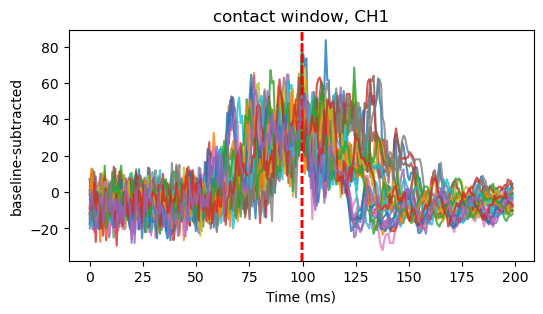

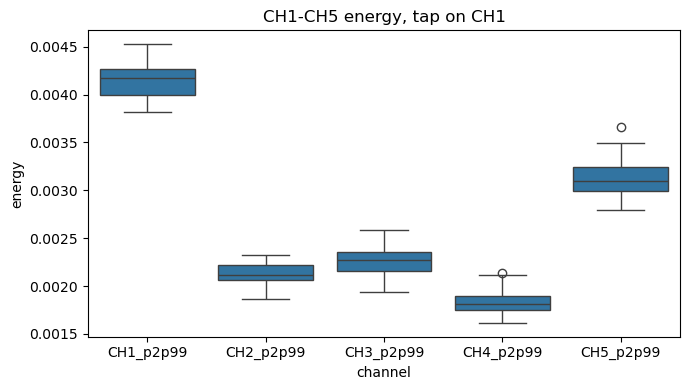

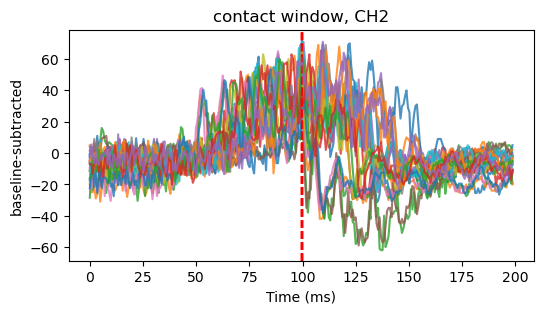

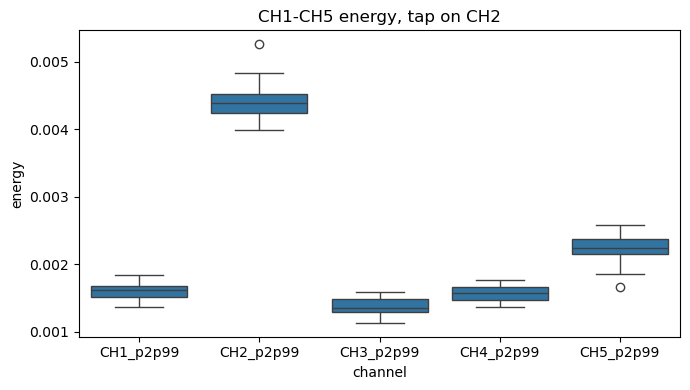

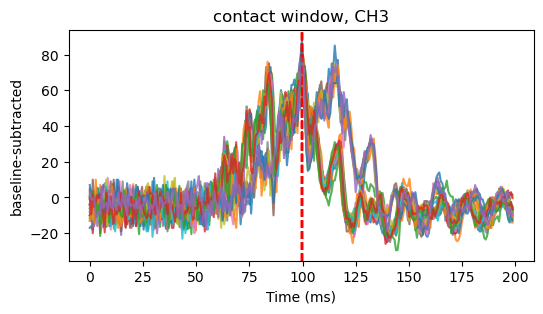

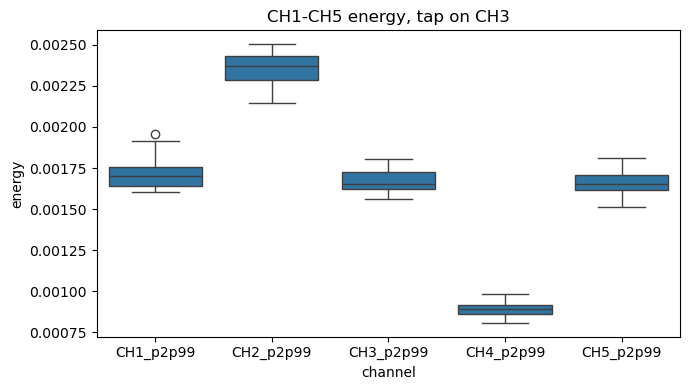

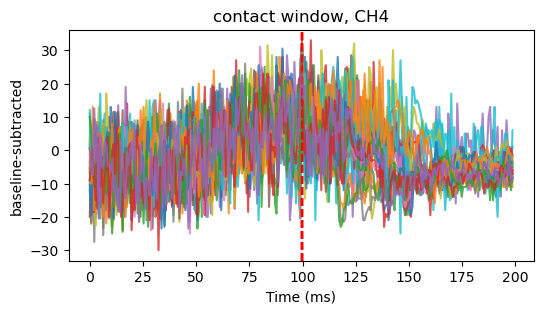

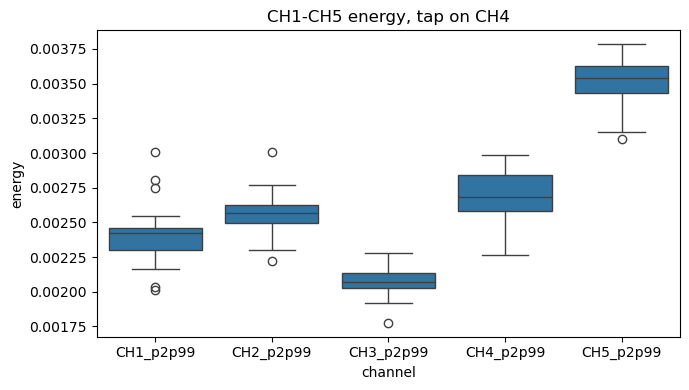

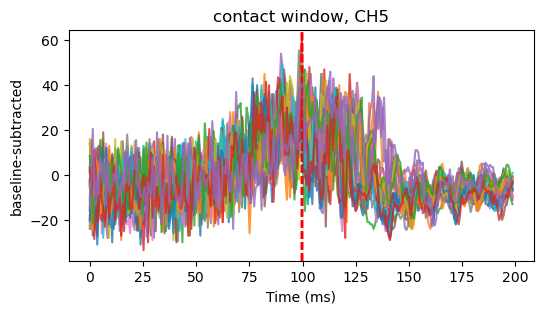

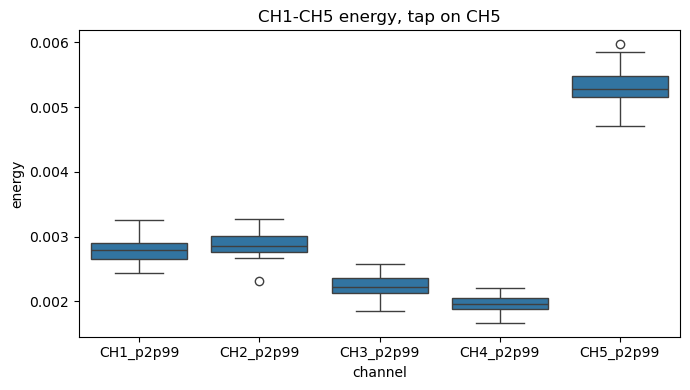

In [44]:
feature_name = "p2p99"
all_feats = []

for ch in range(1,6): # channels 1-5
    query = pl.col("session_id").str.contains(f"ch{ch}_") & \
            pl.col("notes").str.contains(f"dz={dZ_dict[ch]:.2f}")

    filtered = session_index.filter(query).to_dicts()[0]
    fs = filtered["fs_hz"]
    N_cap = filtered["saved_sweeps"]

    pdf = load_session_pandas(filtered, flip=True)
    n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=80, min_sep_ms=500)

    poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=100.0, post_ms=100.0)

    f = plot_poke_windows(poke_windows, fs, ch=f"CH{ch}", n=len(poke_windows),
                      title=f"contact window, CH{ch}")
    ax = f.axes[0]
    ax.set_title("Contact window, CH5")

    force_peaks, F = force_peak_detection(pdf_trim, fs, height=5e3, min_sep_ms=500)
    assert(len(force_peaks) == len(final_peaks)), f"Force peak count {len(force_peaks)} does not match poke peak count {len(final_peaks)}"

#     # validate that the peaks are real
#     plt.figure()
#     plt.plot(mixed_pos)
#     plt.plot(final_peaks, mixed_pos[final_peaks], "rx")
#     plt.title(f"channel {ch} detected {len(final_peaks)} pokes")

#     plt.figure()
#     plt.plot(F)
#     plt.plot(force_peaks, F[force_peaks], "rx")
#     plt.title(f"force channel detected {len(force_peaks)} pokes")

    features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=50.0, pre_ms=50.0, post_ms=100.0)

    peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.98)

    features["force_peak"] = peak_fs
    features["channel_tapped"] = ch
    all_feats.append(features)
    feature_cols = features.columns.drop("force_peak")
    
    df_norm = features.copy()
    df_norm[feature_cols] = df_norm[feature_cols].div(df_norm["force_peak"], axis=0)
    
    eng_cols = [f"{ch}_{feature_name}" for ch in CHS]
    eng_long = df_norm[eng_cols].melt(var_name="channel", value_name="energy")
    
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=eng_long, x="channel", y="energy")
    plt.title(f"CH1-CH5 energy, tap on CH{ch}")
    plt.tight_layout()

    plt.savefig(f"figs/tap_ch{ch}_{feature_name}.png")


In [45]:
all_feats = pd.concat(all_feats, ignore_index=True)
all_feats["force_peak_newton"] = all_feats["force_peak"] / Z_FORCE_SENSOR_TO_NEWTON
# all_feats.to_csv("sensor_calibration_features.csv", index=False)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
y = all_feats["force_peak"].to_numpy().reshape(-1, 1) / Z_FORCE_SENSOR_TO_NEWTON
X = all_feats["Ch"]

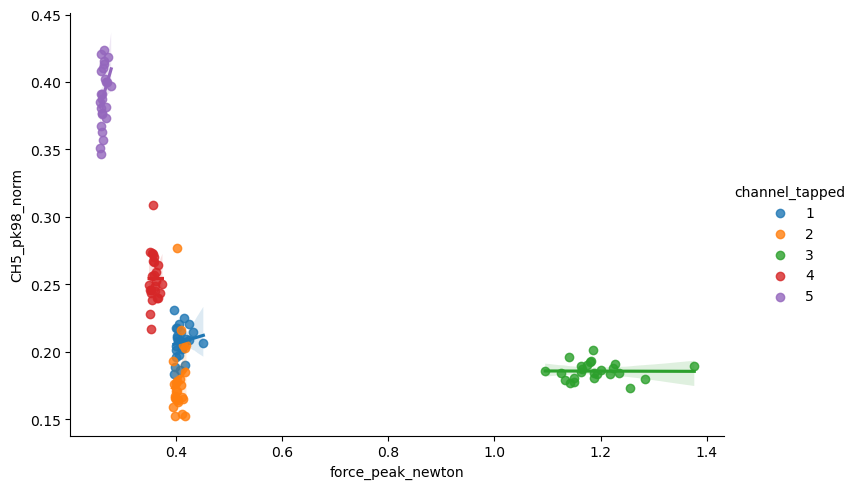

In [61]:
sns.lmplot(data=all_feats, x="force_peak_newton", y="CH5_pk98_norm", hue="channel_tapped", aspect=1.5)

In [38]:
ch_tapped = 5
all_feats_sub = all_feats[all_feats["channel_tapped"] == ch_tapped]

# pick only CHx_p2p99 columns
p2p_cols = all_feats_sub.filter(regex=r"^CH\d+_p2p99$").columns

# keep any metadata columns you want to carry through
id_cols = [c for c in ["dz", "force_peak"] if c in all_feats_sub.columns]

p2p_long = all_feats_sub.melt(
    id_vars=id_cols,
    value_vars=p2p_cols,
    var_name="ch_feature",
    value_name="p2p99",
)

# extract channel (as int). Use .astype(str) if you prefer "1","2",...
p2p_long["Channel"] = p2p_long["ch_feature"].str.extract(r"^CH(\d+)_p2p99$").astype(int)

# optional: drop old combined name
p2p_long = p2p_long.drop(columns="ch_feature")

p2p_long["force_peak_newton"] = p2p_long["force_peak"] / Z_FORCE_SENSOR_TO_NEWTON

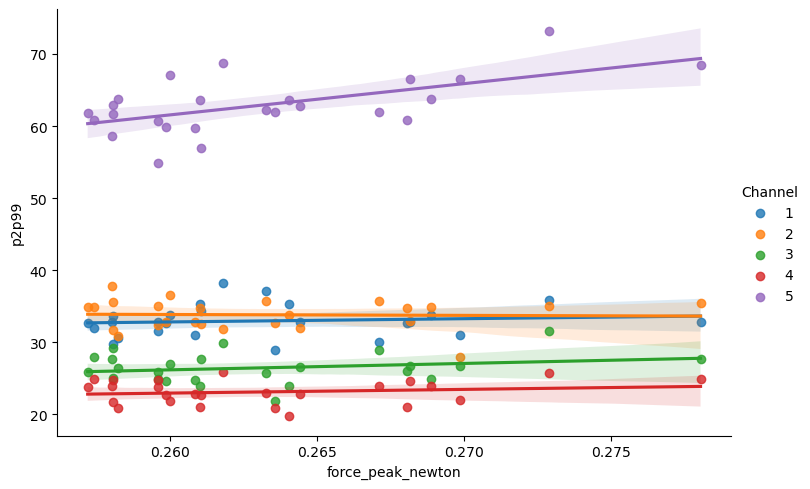

In [39]:
sns.lmplot(data=p2p_long, x="force_peak_newton", y="p2p99", hue="Channel", aspect=1.5)